In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
def get_results(df, feature, loss):
    groupby_features = df.columns.difference(['trial', loss]).tolist()
    avg_df = df.groupby(groupby_features).agg(['mean', 'std'])[loss].reset_index()
    res = avg_df.loc[avg_df.groupby(feature)['mean'].idxmin()].reset_index()
    return res

In [18]:

def plot(gan_df, gt_df, feature, loss, title):
    res_gan_df = get_results(gan_df, feature, loss)
    res_gt_df = get_results(gt_df,feature, loss)

    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))
    # Plot for res_gan_df
    axes[0].plot(res_gan_df[feature], res_gan_df['mean'], label='GAN', marker="o", color="purple")
    axes[0].fill_between(res_gan_df[feature], res_gan_df['mean'] - res_gan_df['std'], res_gan_df['mean'] + res_gan_df['std'], alpha=0.2, color='purple')
    axes[0].set_title('GAN HP Search')
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel('mean ' + loss)
    axes[0].legend()

    # Plot for res_gt_df
    axes[1].plot(res_gt_df[feature], res_gt_df['mean'], label='GT', color='green', marker="o")
    axes[1].fill_between(res_gt_df[feature], res_gt_df['mean'] - res_gt_df['std'], res_gt_df['mean'] + res_gt_df['std'], alpha=0.2, color='green')
    axes[1].set_title('GT HP Search')
    axes[1].set_xlabel(feature)
    axes[1].set_ylabel('mean ' + loss)
    axes[1].legend()

    plt.suptitle(title + ": " + feature + " HP Search")
    plt.tight_layout()
    plt.savefig(f'figs/{title}_{feature}.pdf')

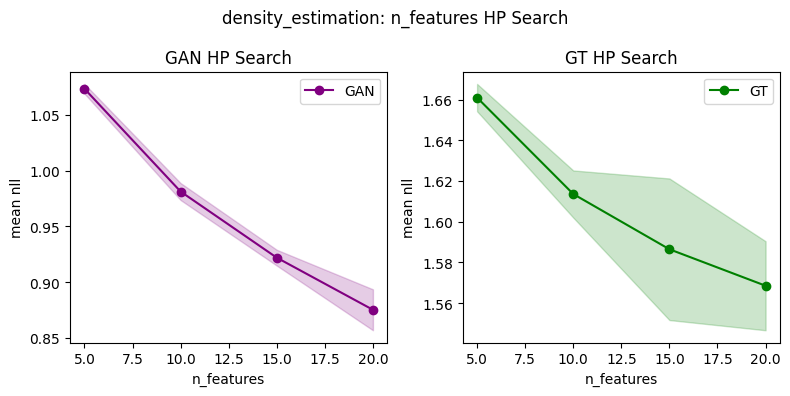

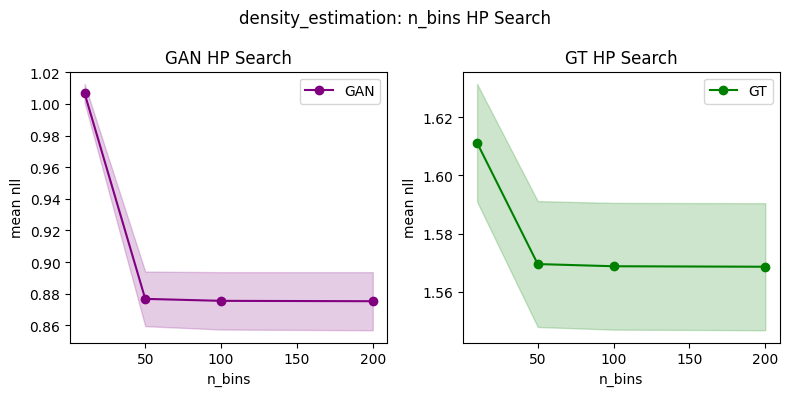

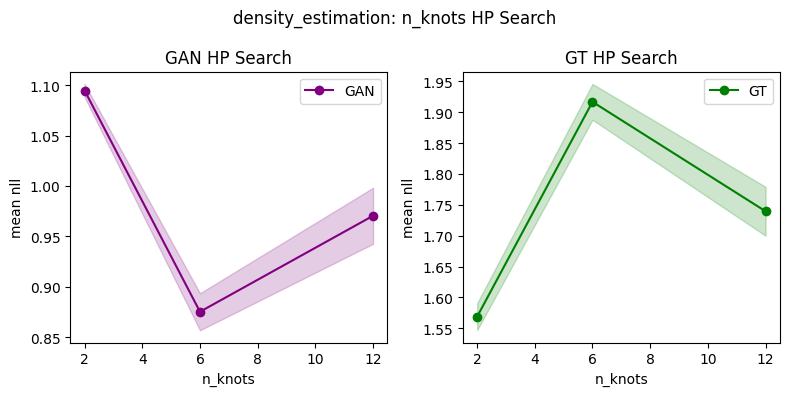

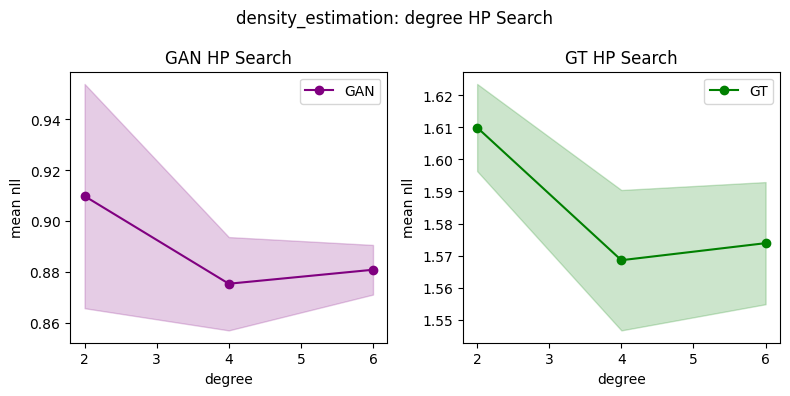

In [19]:
gan_df = pd.read_csv('results/density_estimation_gan_continuous_rate.csv')
gt_df = pd.read_csv('results/density_estimation_gt_continuous_rate.csv')
feature = 'n_features'
loss = 'nll'
title = 'density_estimation'
for feature in ['n_features', 'n_bins', 'n_knots', 'degree']:
    plot(gan_df, gt_df, feature, loss, title)

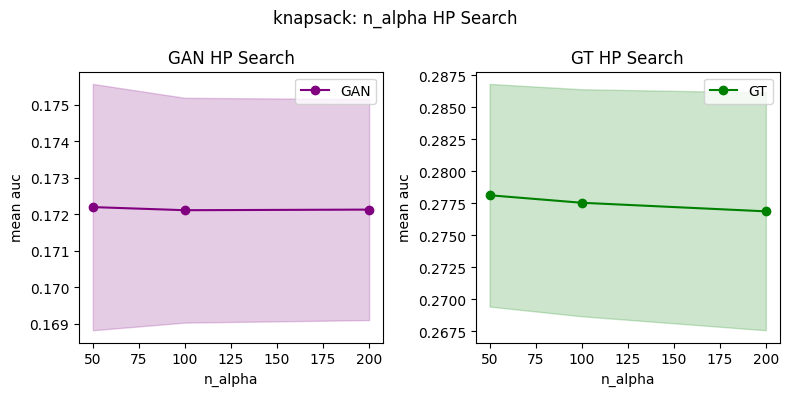

In [21]:
gan_df = pd.read_csv('results/n_alpha_gan_continuous_rate.csv')
gt_df = pd.read_csv('results/n_alpha_gt_continuous_rate.csv')
feature = 'n_alpha'
loss = 'auc'
title = 'knapsack'
plot(gan_df, gt_df, feature, loss, title)

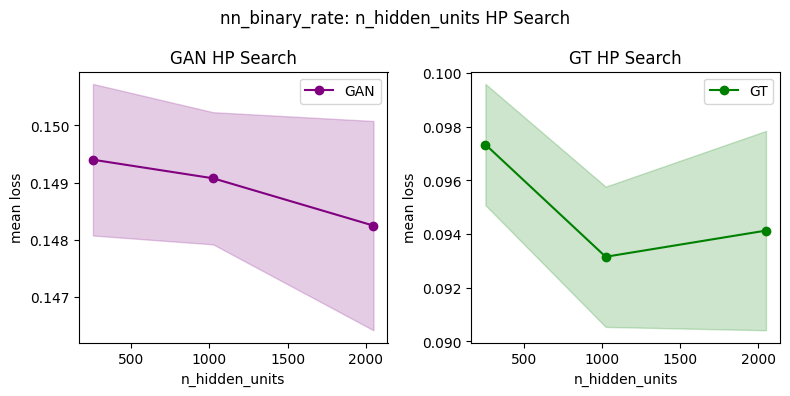

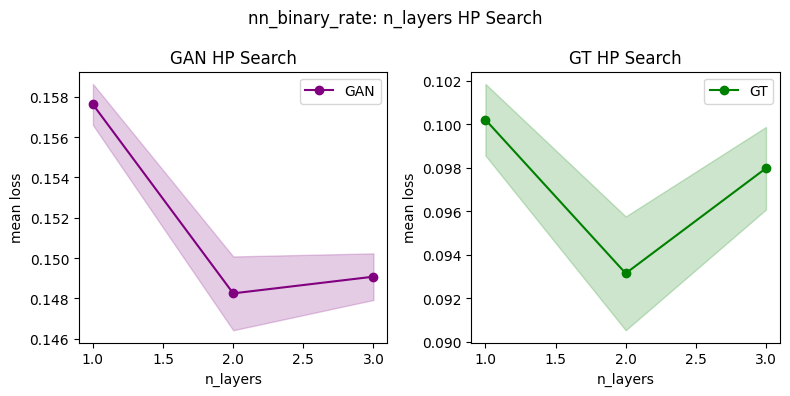

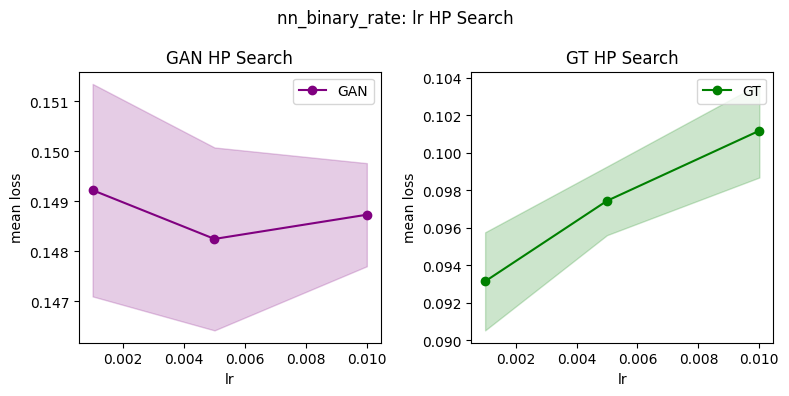

In [29]:
gan_df = pd.read_csv('results/nn_gan_binary_rate.csv')
gt_df = pd.read_csv('results/nn_gt_binary_rate.csv')
loss = 'loss'
title = 'nn_binary_rate'
for feature in ['n_hidden_units', 'n_layers', 'lr']:
    plot(gan_df, gt_df, feature, loss, title)

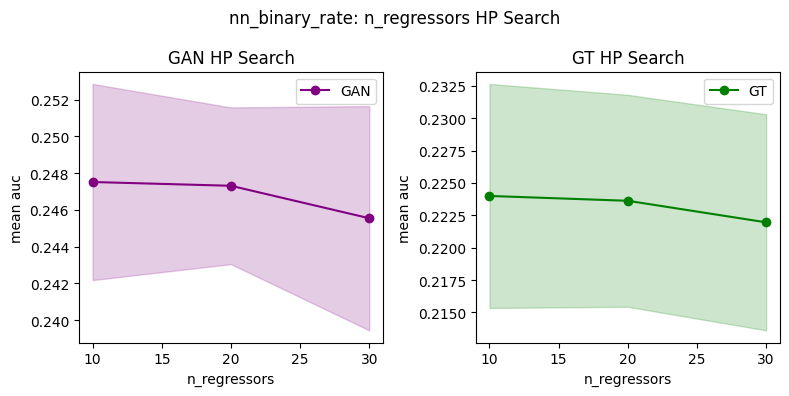

In [30]:
gan_df = pd.read_csv('results/n_regressors_gan_binary_rate.csv')
gt_df = pd.read_csv('results/n_regressors_gt_binary_rate.csv')
loss = 'auc'
title = 'nn_binary_rate'
feature = 'n_regressors'
plot(gan_df, gt_df, feature, loss, title)

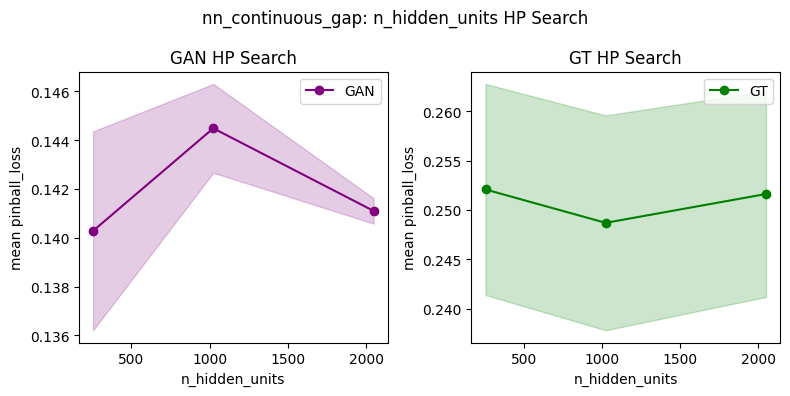

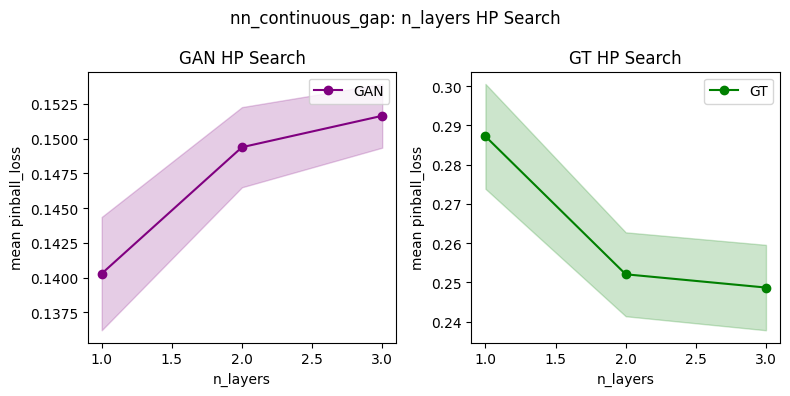

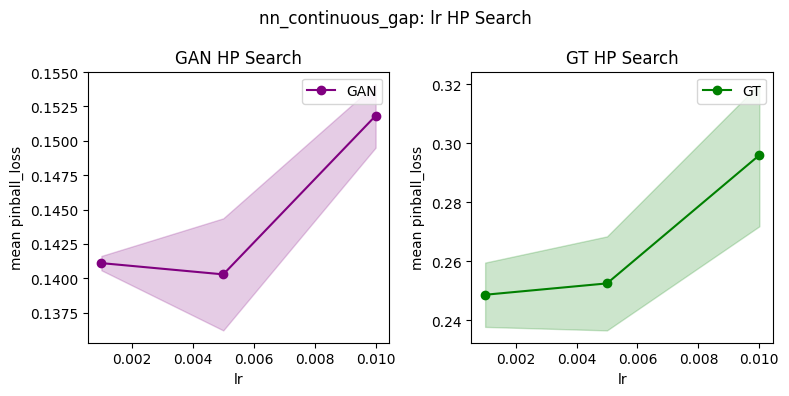

In [22]:
gan_df = pd.read_csv('results/nn_gan_continuous_gap.csv')
gt_df = pd.read_csv('results/nn_gt_continuous_gap.csv')
loss = 'pinball_loss'
title = 'nn_continuous_gap'
for feature in ['n_hidden_units', 'n_layers', 'lr']:
    plot(gan_df, gt_df, feature, loss, title)


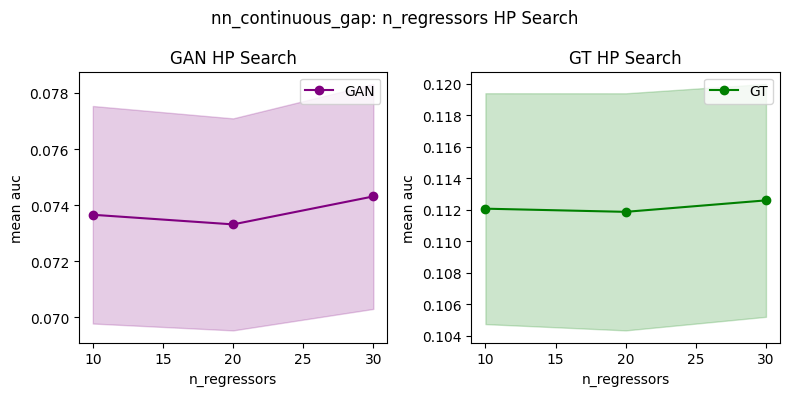

In [27]:
gan_df = pd.read_csv('results/n_regressors_gan_continuous_gap.csv')
gt_df = pd.read_csv('results/n_regressors_gt_continuous_gap.csv')
loss = 'auc'
title = 'nn_continuous_gap'
feature = 'n_regressors'
plot(gan_df, gt_df, feature, loss, title)

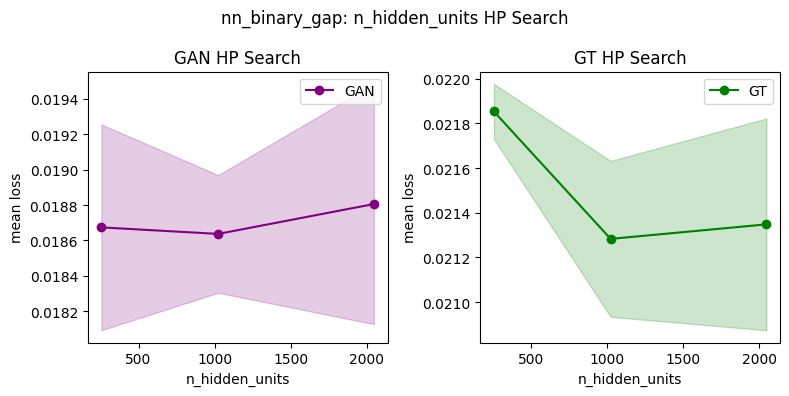

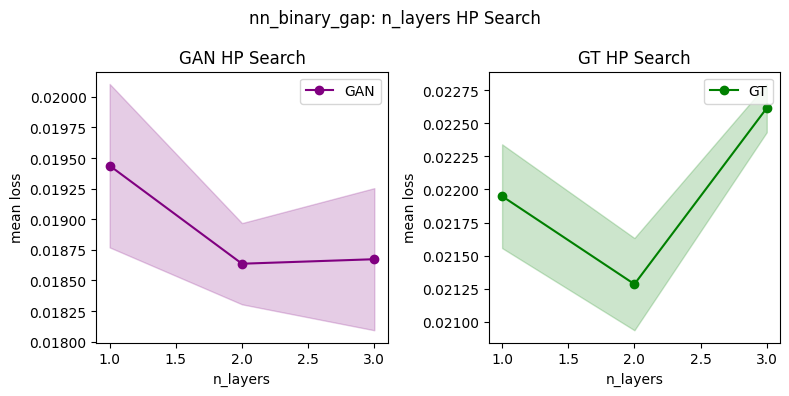

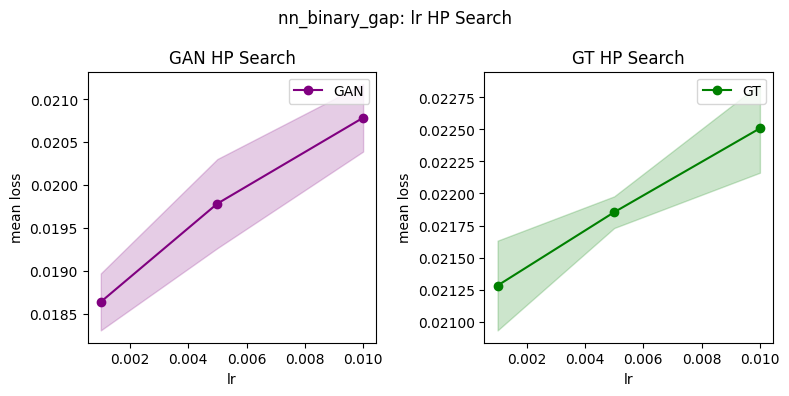

In [31]:
gan_df = pd.read_csv('results/nn_gan_binary_gap.csv')
gt_df = pd.read_csv('results/nn_gt_binary_gap.csv')
loss = 'loss'
title = 'nn_binary_gap'
for feature in ['n_hidden_units', 'n_layers', 'lr']:
    plot(gan_df, gt_df, feature, loss, title)


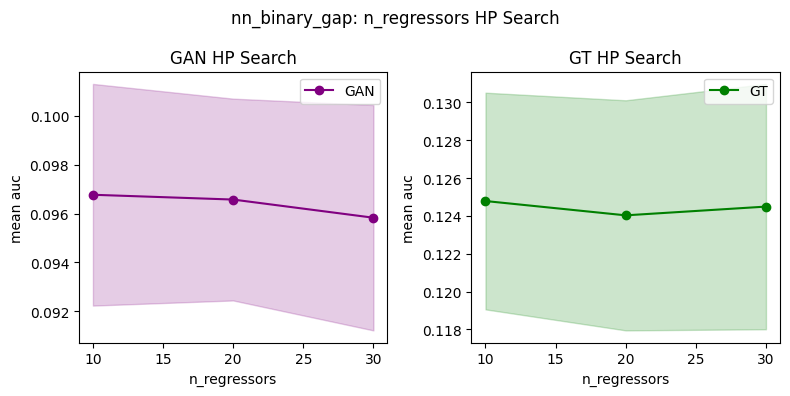

In [32]:
gan_df = pd.read_csv('results/n_regressors_gan_binary_gap.csv')
gt_df = pd.read_csv('results/n_regressors_gt_binary_gap.csv')
loss = 'auc'
title = 'nn_binary_gap'
feature = 'n_regressors'
plot(gan_df, gt_df, feature, loss, title)